# Cook BH – Transcription with Bentham Checkpoint

Evaluation of the Bentham-fine-tuned TrOCR checkpoint (`checkpoints/best`) on the Cook dataset.  
No further training — the checkpoint is used as-is.

| Split | Source |
|---|---|
| Train | `data/train_set_line_crops/` — alle Seiten außer den 6 Val-Seiten |
| Val | `data/train_set_line_crops/` — B1_P231, B2_P224, B3_P276, B4_P282, B5_P020, B6_P020 |
| Test | `data/test_set_line_crops/` |

In [1]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import random
import numpy as np
import torch
from pathlib import Path

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

ROOT             = Path("..")
TRAIN_CROPS_DIR  = ROOT / "data" / "train_set_line_crops"
TEST_CROPS_DIR   = ROOT / "data" / "test_set_line_crops"
CHECKPOINT_DIR   = ROOT / "checkpoints" / "best"

print(f"Random seed    : {SEED}")
for p in [TRAIN_CROPS_DIR, TEST_CROPS_DIR, CHECKPOINT_DIR]:
    print(f"  {'✓' if p.exists() else '✗'} {p}")

Random seed    : 42
  ✓ ../data/train_set_line_crops
  ✓ ../data/test_set_line_crops
  ✓ ../checkpoints/best


## Step 1 – Load Data

In [2]:
import pandas as pd

def build_dataframe(crops_dir: Path) -> pd.DataFrame:
    records = []
    for page_dir in sorted(crops_dir.iterdir()):
        if not page_dir.is_dir():
            continue
        for img_path in sorted(page_dir.glob("*.jpg")):
            txt_path = img_path.with_suffix(".txt")
            if txt_path.exists():
                transcription = txt_path.read_text(encoding="utf-8").strip()
                records.append({
                    "image_path":    str(img_path),
                    "page":          page_dir.name,
                    "transcription": transcription,
                })
    return pd.DataFrame(records)


df_all_train = build_dataframe(TRAIN_CROPS_DIR)
df_test      = build_dataframe(TEST_CROPS_DIR)

VAL_PAGES = {"B1_P231", "B2_P224", "B3_P276", "B4_P282", "B5_P020", "B6_P020"}

df_train = df_all_train[~df_all_train["page"].isin(VAL_PAGES)].reset_index(drop=True)
df_val   = df_all_train[ df_all_train["page"].isin(VAL_PAGES)].reset_index(drop=True)

print(f"Train pages : {sorted(df_train['page'].unique())}")
print(f"Val pages   : {sorted(df_val['page'].unique())}")
print(f"Test pages  : {sorted(df_test['page'].unique())}")
print()
print(f"Train lines : {len(df_train):>5}")
print(f"Val lines   : {len(df_val):>5}")
print(f"Test lines  : {len(df_test):>5}")

Train pages : ['B1_P057', 'B1_P108', 'B1_P146', 'B1_P151', 'B2_P014', 'B2_P025', 'B2_P052', 'B2_P094', 'B3_P015', 'B3_P069', 'B3_P105', 'B3_P189', 'B4_P019', 'B4_P071', 'B4_P123', 'B4_P171', 'B5_P014', 'B5_P015', 'B5_P016', 'B5_P017', 'B6_P014', 'B6_P015', 'B6_P016', 'B6_P017']
Val pages   : ['B1_P231', 'B2_P224', 'B3_P276', 'B4_P282', 'B5_P020', 'B6_P020']
Test pages  : ['B1_P_206', 'B2_P_260', 'B3_P_162', 'B4_P_178', 'B5_P_279', 'B6_P_060']

Train lines :   726
Val lines   :   194
Test lines  :   189


## Step 2 – Build Dataset Objects

In [3]:
from transformers import TrOCRProcessor
from PIL import Image

processor = TrOCRProcessor.from_pretrained(CHECKPOINT_DIR)
print(f"Processor loaded from: {CHECKPOINT_DIR}")

Processor loaded from: ../checkpoints/best


In [4]:
from torch.utils.data import Dataset, DataLoader


class CookDataset(Dataset):
    def __init__(self, df, processor, max_target_length=128):
        self.df                = df
        self.processor         = processor
        self.max_target_length = max_target_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB")
        pixel_values = self.processor(
            images=img, return_tensors="pt"
        ).pixel_values.squeeze(0)

        labels = self.processor.tokenizer(
            row["transcription"],
            padding="max_length",
            max_length=self.max_target_length,
            truncation=True,
            return_tensors="pt",
        ).input_ids.squeeze(0)
        labels[labels == self.processor.tokenizer.pad_token_id] = -100

        return {"pixel_values": pixel_values, "labels": labels}


train_loader = DataLoader(CookDataset(df_train, processor), batch_size=16, shuffle=False, num_workers=0)
val_loader   = DataLoader(CookDataset(df_val,   processor), batch_size=16, shuffle=False, num_workers=0)
test_loader  = DataLoader(CookDataset(df_test,  processor), batch_size=16, shuffle=False, num_workers=0)

print("DataLoaders OK.")

DataLoaders OK.


## Step 3 – Load Bentham Checkpoint

In [5]:
from transformers import VisionEncoderDecoderModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model = VisionEncoderDecoderModel.from_pretrained(CHECKPOINT_DIR)
model.to(device)
model.eval()
print(f"Model loaded from: {CHECKPOINT_DIR}")

Device: cuda


Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

Model loaded from: ../checkpoints/best


## Step 4 – Evaluation

In [6]:
import evaluate
from tqdm.notebook import tqdm

cer_metric = evaluate.load("cer")
wer_metric = evaluate.load("wer")


def run_inference(dataloader):
    all_preds, all_refs = [], []
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Inferring", leave=False):
            pixel_values  = batch["pixel_values"].to(device)
            labels        = batch["labels"].clone()
            generated_ids = model.generate(pixel_values, max_new_tokens=128)
            preds = processor.batch_decode(generated_ids, skip_special_tokens=True)
            labels[labels == -100] = processor.tokenizer.pad_token_id
            refs  = processor.batch_decode(labels, skip_special_tokens=True)
            all_preds.extend(preds)
            all_refs.extend(refs)
    return all_preds, all_refs


print("Running inference on all splits …")
train_preds, train_refs = run_inference(train_loader)
val_preds,   val_refs   = run_inference(val_loader)
test_preds,  test_refs  = run_inference(test_loader)

def metrics(preds, refs):
    return (
        cer_metric.compute(predictions=preds, references=refs),
        wer_metric.compute(predictions=preds, references=refs),
    )

train_cer, train_wer = metrics(train_preds, train_refs)
val_cer,   val_wer   = metrics(val_preds,   val_refs)
test_cer,  test_wer  = metrics(test_preds,  test_refs)

results = pd.DataFrame([
    {"Split": "Train", "Lines": len(train_refs), "CER": round(train_cer, 4), "WER": round(train_wer, 4)},
    {"Split": "Val",   "Lines": len(val_refs),   "CER": round(val_cer,   4), "WER": round(val_wer,   4)},
    {"Split": "Test",  "Lines": len(test_refs),  "CER": round(test_cer,  4), "WER": round(test_wer,  4)},
])
print(results.to_string(index=False))

Running inference on all splits …


Inferring:   0%|          | 0/46 [00:00<?, ?it/s]

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer RobertaTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Inferring:   0%|          | 0/13 [00:00<?, ?it/s]

Inferring:   0%|          | 0/12 [00:00<?, ?it/s]

Split  Lines    CER    WER
Train    726 0.1962 0.5389
  Val    194 0.1726 0.4748
 Test    189 0.1874 0.4868


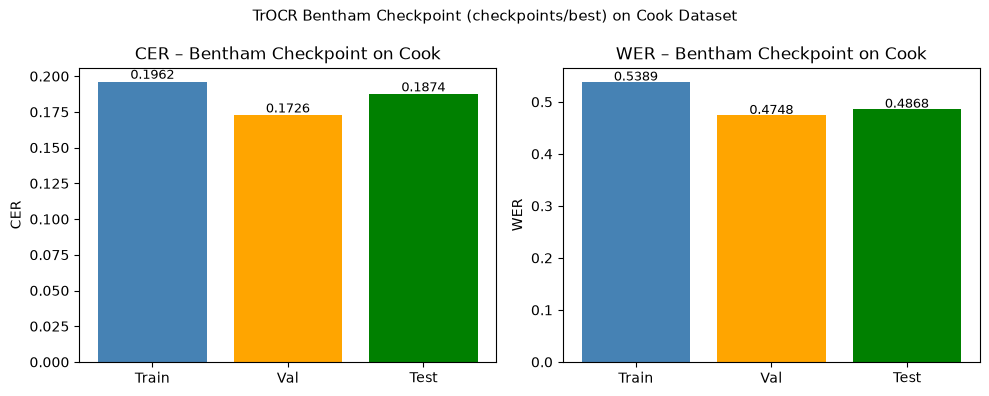

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
x      = range(len(results))
colors = ["steelblue", "orange", "green"]

for ax, metric in zip(axes, ["CER", "WER"]):
    ax.bar(x, results[metric], color=colors)
    ax.set_xticks(x)
    ax.set_xticklabels(results["Split"])
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} – Bentham Checkpoint on Cook")
    for i, v in enumerate(results[metric]):
        ax.text(i, v + 0.002, f"{v:.4f}", ha="center", fontsize=9)

plt.suptitle("TrOCR Bentham Checkpoint (checkpoints/best) on Cook Dataset", fontsize=11)
plt.tight_layout()
plt.show()

## Step 5 – Qualitative Examples (Test Set)

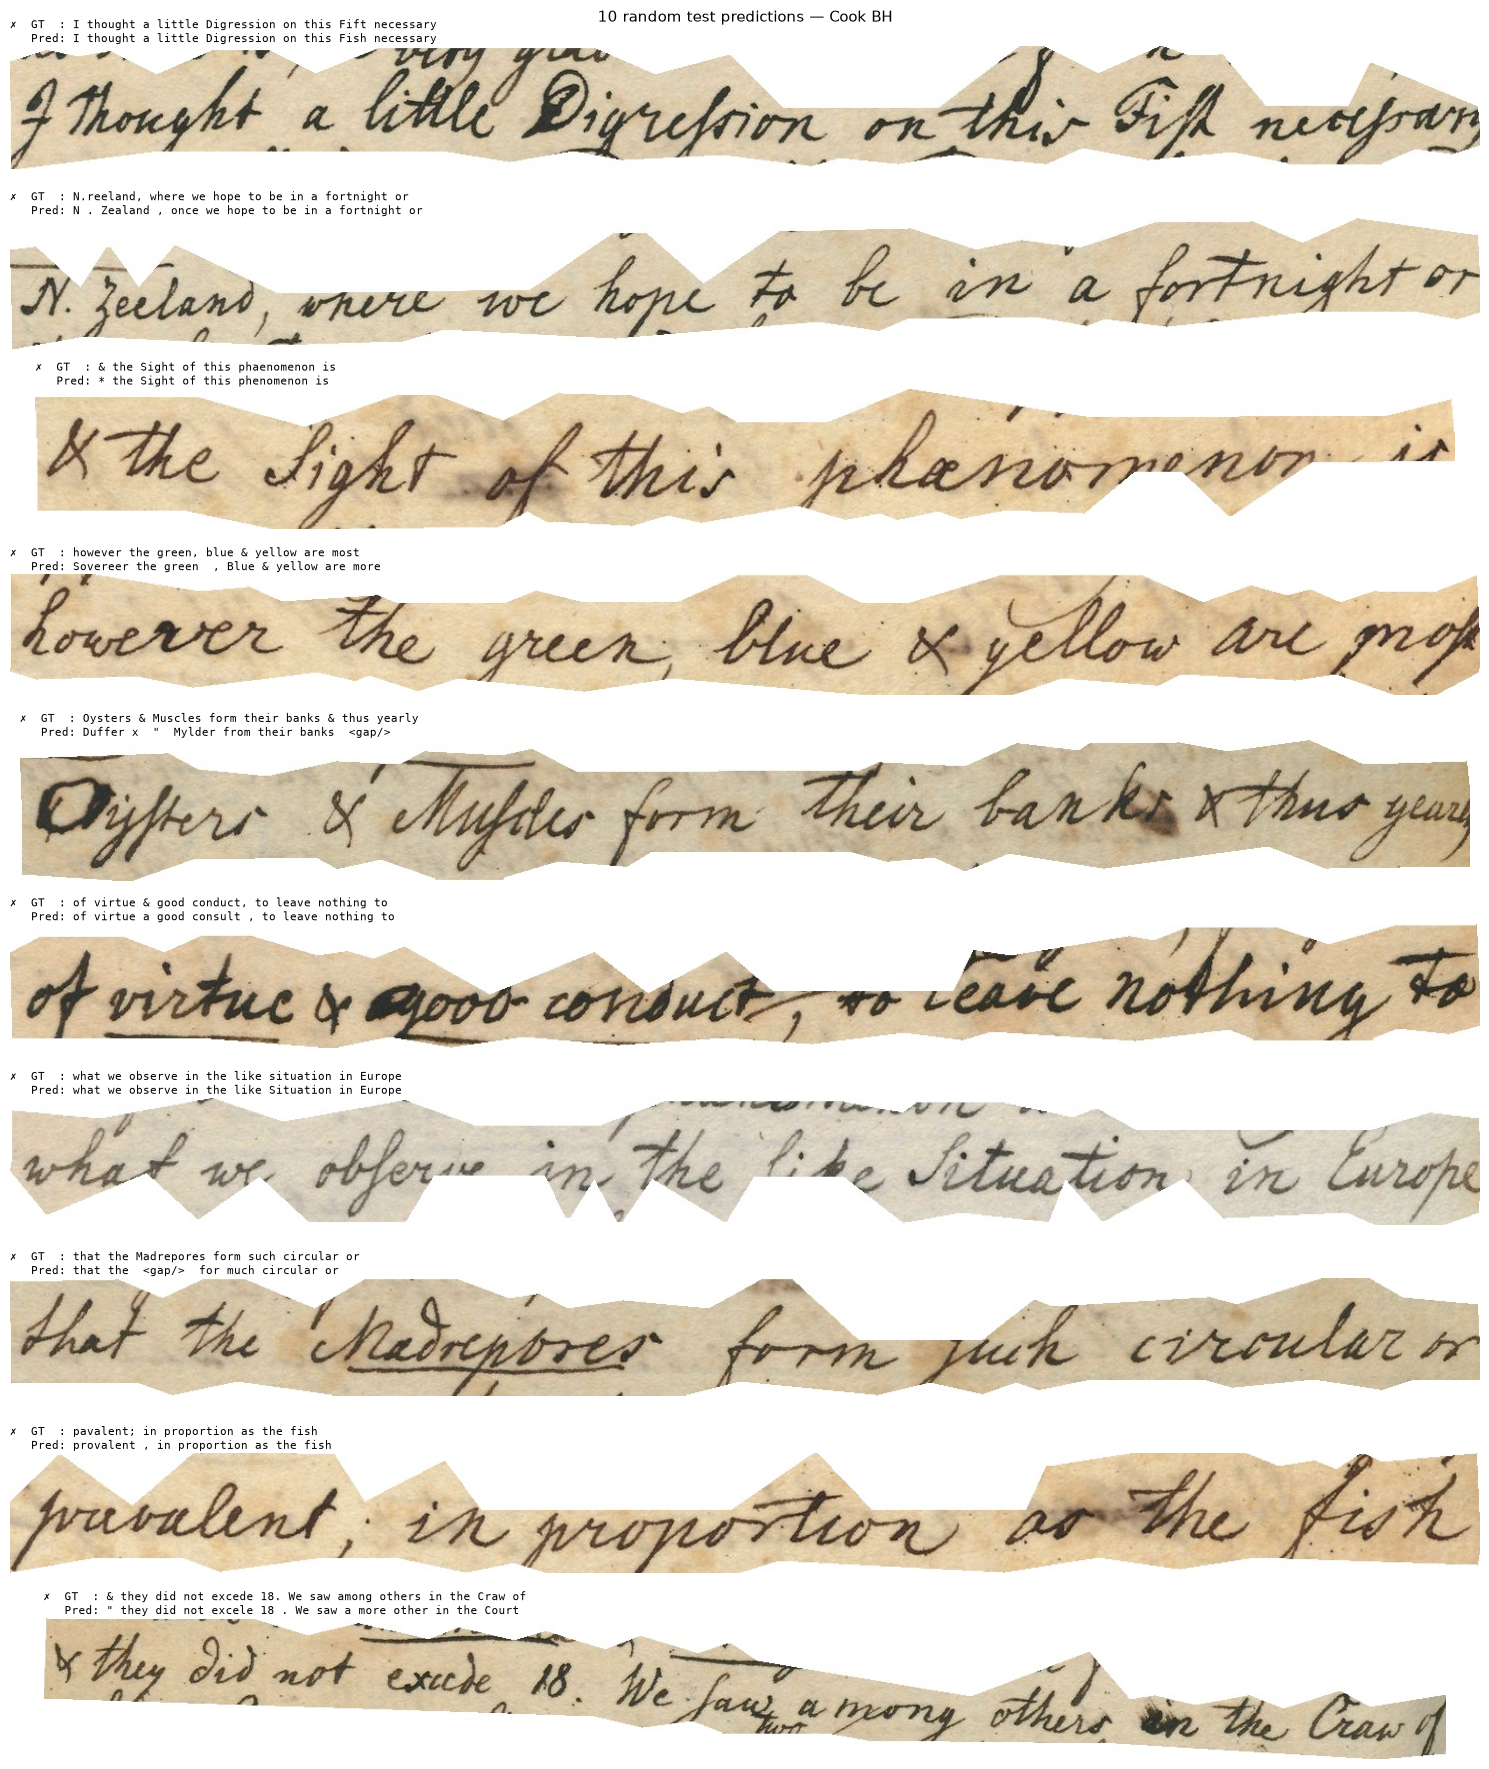

In [8]:
sample_idx = df_test.sample(10, random_state=SEED).index.tolist()

fig, axes = plt.subplots(10, 1, figsize=(15, 18))
for ax, idx in zip(axes, sample_idx):
    row   = df_test.iloc[idx]
    img   = Image.open(row["image_path"]).convert("RGB")
    pred  = test_preds[idx]
    ref   = test_refs[idx]
    match = "✓" if pred.strip() == ref.strip() else "✗"
    ax.imshow(img)
    ax.set_title(
        f"{match}  GT  : {ref}\n   Pred: {pred}",
        fontsize=8, loc="left", pad=3, family="monospace",
    )
    ax.axis("off")
plt.suptitle("10 random test predictions — Cook BH", fontsize=11)
plt.tight_layout()
plt.show()

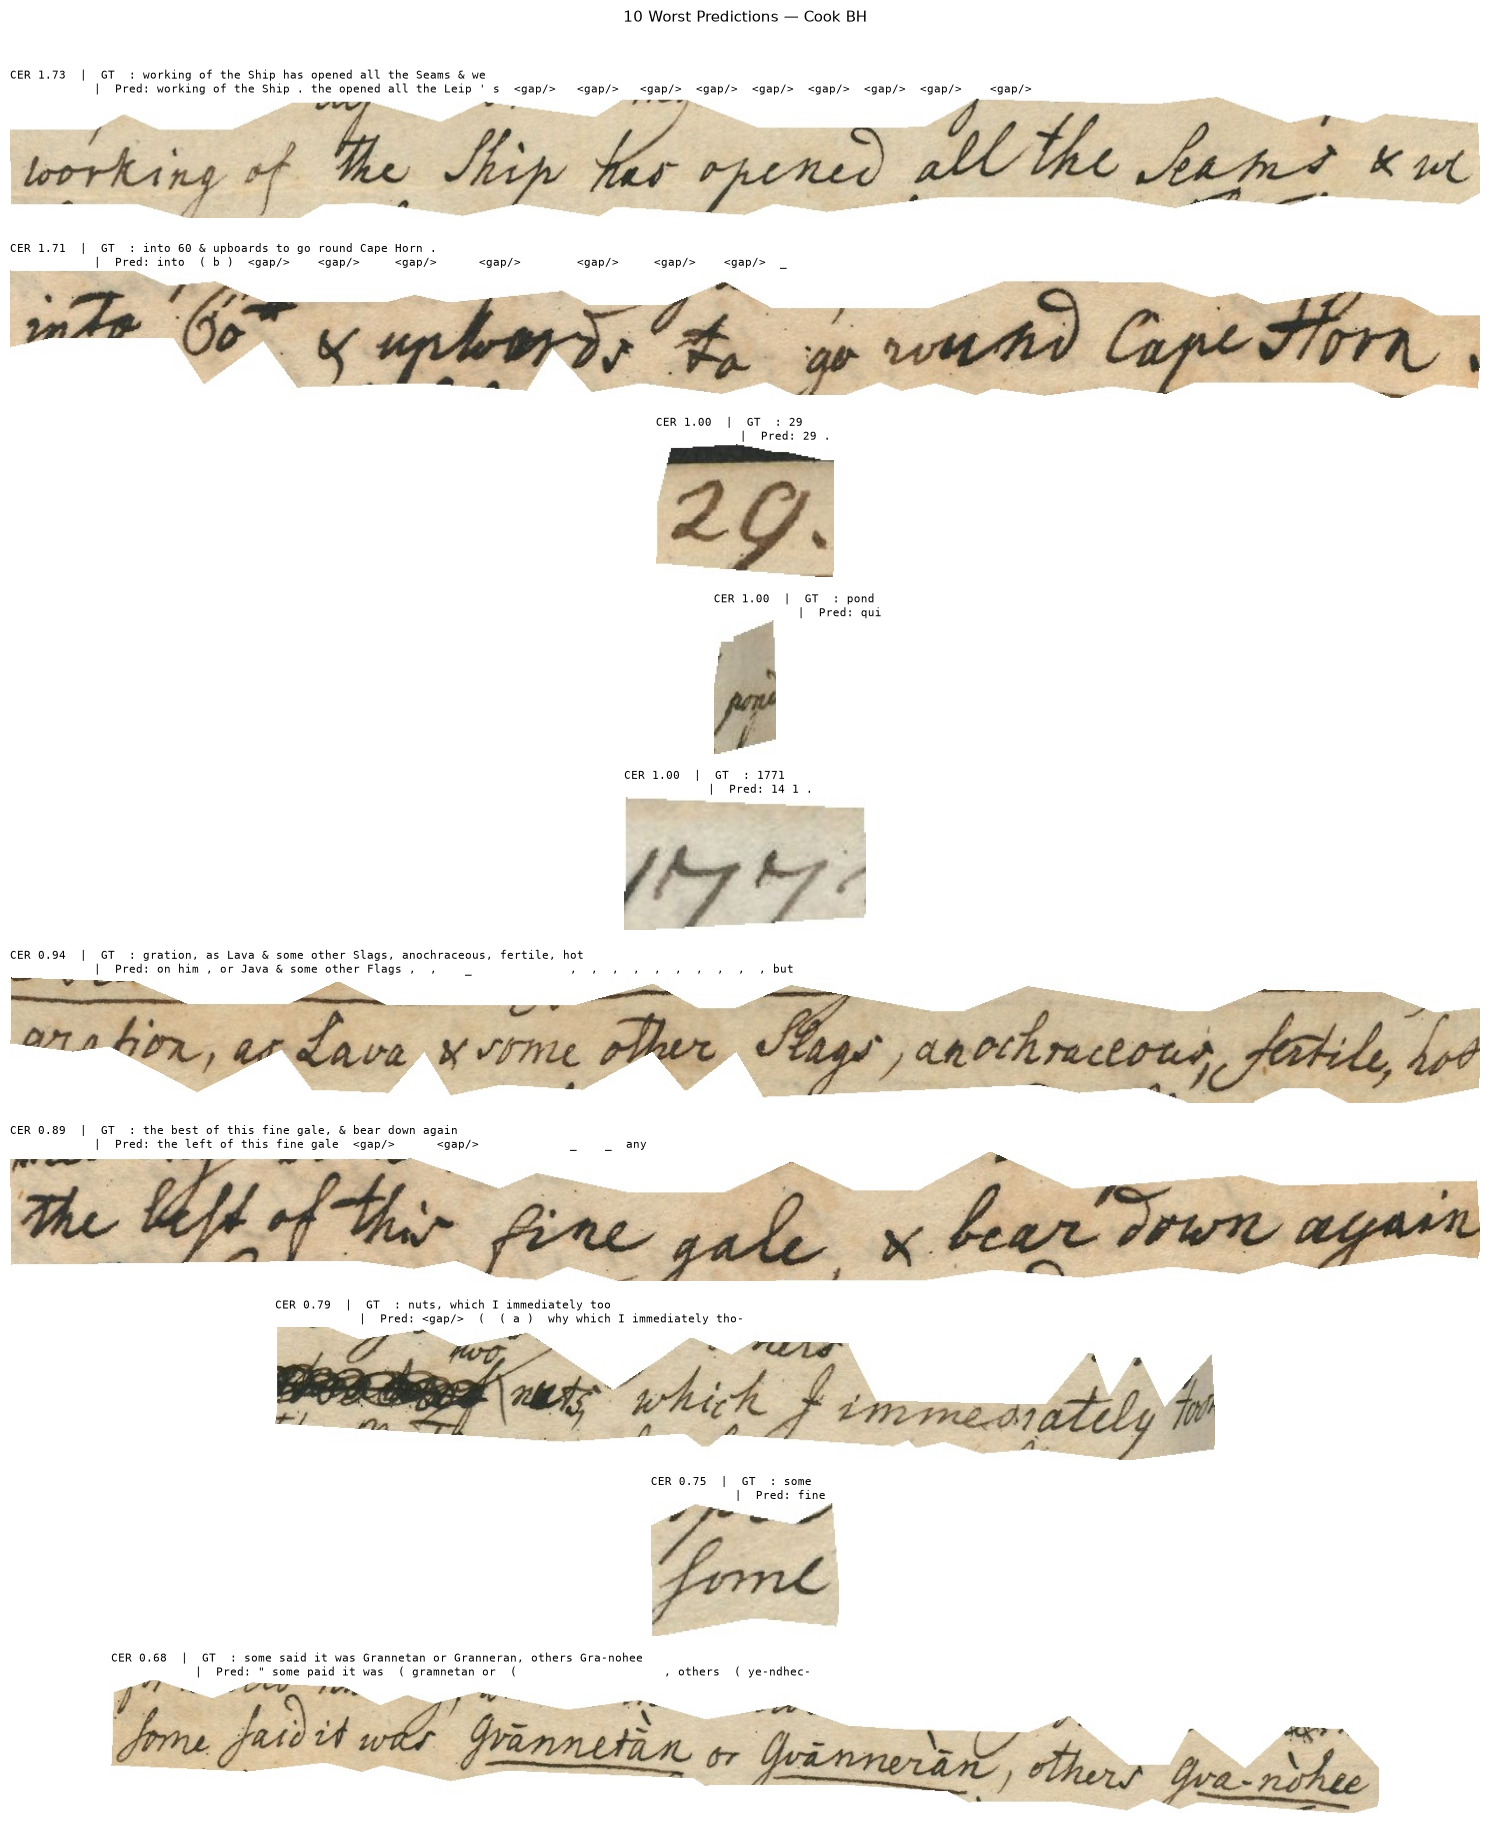

In [9]:
from jiwer import cer as line_cer

errors = sorted(
    [(line_cer(ref, pred), idx, ref, pred)
     for idx, (pred, ref) in enumerate(zip(test_preds, test_refs)) if ref.strip()],
    reverse=True,
)

fig, axes = plt.subplots(10, 1, figsize=(15, 18))
for ax, (c, idx, ref, pred) in zip(axes, errors[:10]):
    row = df_test.iloc[idx]
    img = Image.open(row["image_path"]).convert("RGB")
    ax.imshow(img)
    ax.set_title(
        f"CER {c:.2f}  |  GT  : {ref}\n"
        f"            |  Pred: {pred}",
        fontsize=8, loc="left", pad=3, family="monospace",
    )
    ax.axis("off")

plt.suptitle("10 Worst Predictions — Cook BH", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()